In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


We derive the theoretical standart deviation of our model, and plot it agains the empirical one. Refer to the paper for the calculations below.

We got the transition probability matrix as:

P$$  = [[0.59758503,0.40241497], [0.44562421 0.55437579]]$$, denote as $P_{uu} = 0.597, P_{ud} = 0.402$

In [3]:
P = np.array([[0.59758503,0.40241497],[0.44562421 ,0.55437579]])

$$\pi = [0.52547614, 0.47452386]

In [4]:
pi = np.array([0.52547614, 0.47452386])

$$\implies \Pi^* = [[0.52547614, 0.47452386],[0.52547614, 0.47452386]]

In [5]:
Pi = np.array([pi,pi])

Took $$ a(1) = 0.5, a(-1) =-0.5 \implies a^* = 0.02547613999999998$$

In [6]:
a = np.array([0.5,-0.5])
a_star = np.array([0.02547613999999998])

In [7]:
b = a-a_star
print(b)

[ 0.47452386 -0.52547614]


$$\implies b(1) = 0.47452386, b(-1) = -0.52547614 \implies b^T = [ 0.47452386 -0.52547614]$$

$$ g:= (P + \Pi^* -I){^-1} b$$

In [8]:
A= np.linalg.inv(P + Pi - np.eye(2))

In [9]:
print(A)

[[-0.0340782  1.0340782]
 [ 1.1451126 -0.1451126]]


In [10]:
g = np.matmul(A,b)


In [11]:
print(g)

[-0.55955434  0.61963646]


$$v(1) = b(1)^2 + [ (g(-1)-g(1))^2 P(1,-1)] - 2b(1) [ (g(-1)-g(1)) P(1,-1)]

In [12]:
# v(1) = b(1)^2 + [ (g(-1)-g(1))^2 * P(1,-1)] - 2*b(1) * [ (g(-1)-g(1)) * P(1,-1)]
v1 = b[0]**2 + ((g[1]-g[0])**2) * P[0,1] - 2*b[0]*(g[1]-g[0])*P[0,1]
print('v(1) =', v1)
v2 = b[1]**2 + ((g[0]-g[1])**2) * P[1,0] - 2*b[1]*(g[0]-g[1])*P[1,0]
print('v(2) =', v2)

v(1) = 0.33438131620588013
v(2) = 0.3435114348509595


In [13]:
v = np.array([v1,v2])
print(v)

[0.33438132 0.34351143]


$$\sigma ^2 = \pi _1 v(1) + \pi _2 v(2)$$

In [14]:
sigma = np.sqrt(np.matmul(pi,v))

In [15]:
print(sigma)

0.5819912158680758


But we see that we need $$\sigma^* \sqrt{(\frac{\lambda }{1-\hat{h}})}$$

We have $$\lambda = 0.16508945342301887, a =  0.011477956127453995, b =  0.20470834799305934$$

In [ ]:
# Refer to "estimation.ipynb" for these parameters.
lamb = 0.16508945342301887

a=0.011477956127453995

b = 0.20470834799305934

We have $$h(t,z) = z a \exp(-bt)$$

$$H(z):= \int _0 ^ \infty h(t,z) dt$$ 

Thus in our case we have $$H(z) = \frac{az}{b}$$

Now we take the density of Z as $f(z)$

An observation before gave us $$f(z) = \frac{1}{\sqrt{2 \pi \sigma ^2}} \exp({-1/2 \frac{(z-\mu)^2}{\sigma ^2} })$$

When we fitted , got $$\mu = 13.329567797401769,$$

In [17]:
mu = 13.329567797401769


$$\hat{h} := \int{H(z)f(z)} dz$$

In [18]:
h_hat = a/b * mu

In [19]:
print(h_hat)

0.7473862003013596


In [20]:
par =  (sigma * np.sqrt(lamb/(1-h_hat)))

In [21]:
print(par)

0.47048692523512375


Since we have the theoretical std now, we can plot against the empirical data.

In [22]:
data_interval =  np.linspace(1, +1200, 100)

In [ ]:
# Refer to "std_calculate.ipynb" for these.
std_results = np.genfromtxt("std_results.csv",delimiter=",")
x = std_results[:,0]
y = std_results[:,1]


Regression coefficients (fitted on n >= 200):
Model: y = 12.787256 + 7.123004 * sqrt(x)
Intercept: 12.787256
Slope (C): 7.123004


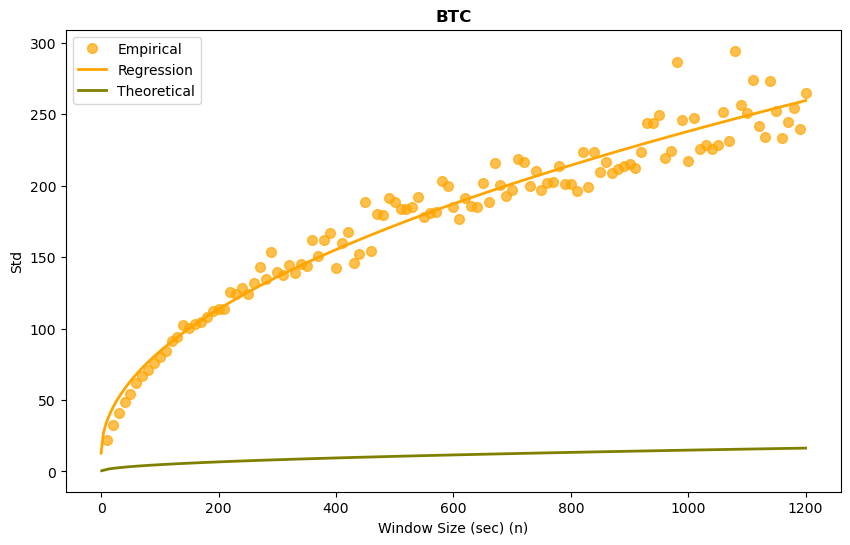

In [26]:
# Add regression line: y = C * sqrt(x), starting from n=200
plt.figure(figsize=(10,6))

"""# Filter data for n >= 200
mask = x >= 200
x_filtered = x[mask]
y_filtered = y[mask]"""

# Fit model: std = C * sqrt(window_size) 
# Transform x to sqrt(x) and fit linear regression
x_sqrt_filtered = np.sqrt(x)
# Fit y = C * sqrt(x)
coeffs = np.polyfit(x_sqrt_filtered, y, 1) 

# Print coefficients
print(f"\nRegression coefficients (fitted on n >= 200):")
print(f"Model: y = {coeffs[1]:.6f} + {coeffs[0]:.6f} * sqrt(x)")
print(f"Intercept: {coeffs[1]:.6f}")
print(f"Slope (C): {coeffs[0]:.6f}")

plt.plot(
    x, 
    y, 
    'o',
    color="orange",
    label='Empirical',
    alpha=0.7,
    markersize=7
)



# Create smooth line for plotting, starting from n=200
x_smooth = np.linspace(0, x.max(), 300)
x_smooth_sqrt = np.sqrt(x_smooth)
regression_line = np.polyval(coeffs, x_smooth_sqrt)
plt.plot(x_smooth, regression_line, '-', label='Regression', color="orange", linewidth=2)

plt.plot(data_interval,np.sqrt(data_interval)*par,color = "olive",label = "Theoretical",linewidth = 2 )




plt.title("BTC", fontweight='bold')
plt.xlabel('Window Size (sec) (n)')
plt.ylabel('Std')
plt.legend()

plt.show()

In [29]:
print(f"Percent Error:%{((par-7.123004)/7.123004)*100}")

Percent Error:%-93.39482435731998
